In [403]:
import csv
import numpy as np

In [404]:
file = open('data.csv',newline='')
reader = csv.reader(file)
data_list = list(reader)[1:]
print(data_list)

[['1200', '400', '4', '3.09', '0.25', '0.98'], ['1500', '400', '4', '3.71', '0.46', '1.08'], ['1500', '400', '6', '3.61', '0.37', '1.46'], ['1500', '400', '8', '3.49', '0.11', '1.98'], ['1500', '400', '10', '4.3', '0.21', '2.14'], ['2000', '200', '3', '5.24', '0.71', '0.85'], ['2000', '200', '10', '5.28', '0.75', '2.11'], ['2000', '300', '3', '5.33', '1.81', '1.38'], ['2000', '400', '8', '4.07', '0.59', '1.75'], ['2000', '500', '8', '3.94', '0.65', '1.49'], ['2000', '500', '3', '4.31', '1.22', '1.11'], ['2500', '100', '5', '10.7', '2.83', '0.82'], ['2500', '150', '5', '8.5', '1.51', '1.04'], ['2500', '150', '7', '8.9', '1.52', '2.06'], ['2500', '200', '5', '8.05', '1.5', '1.05'], ['2500', '200', '7', '8.66', '1.62', '1.89'], ['2500', '250', '5', '8.32', '1.69', '0.78'], ['2500', '400', '3', '5.3', '2.13', '1.1'], ['3000', '150', '5', '8.6', '2.42', '1.16'], ['3000', '150', '7', '9.41', '2.6', '1.53'], ['3000', '200', '5', '8.05', '2.43', '1'], ['3000', '200', '7', '8.8', '2.41', '1.34'

In [405]:
data_array = np.asarray(data_list, dtype=np.float32)
print(data_array)

[[1.20e+03 4.00e+02 4.00e+00 3.09e+00 2.50e-01 9.80e-01]
 [1.50e+03 4.00e+02 4.00e+00 3.71e+00 4.60e-01 1.08e+00]
 [1.50e+03 4.00e+02 6.00e+00 3.61e+00 3.70e-01 1.46e+00]
 [1.50e+03 4.00e+02 8.00e+00 3.49e+00 1.10e-01 1.98e+00]
 [1.50e+03 4.00e+02 1.00e+01 4.30e+00 2.10e-01 2.14e+00]
 [2.00e+03 2.00e+02 3.00e+00 5.24e+00 7.10e-01 8.50e-01]
 [2.00e+03 2.00e+02 1.00e+01 5.28e+00 7.50e-01 2.11e+00]
 [2.00e+03 3.00e+02 3.00e+00 5.33e+00 1.81e+00 1.38e+00]
 [2.00e+03 4.00e+02 8.00e+00 4.07e+00 5.90e-01 1.75e+00]
 [2.00e+03 5.00e+02 8.00e+00 3.94e+00 6.50e-01 1.49e+00]
 [2.00e+03 5.00e+02 3.00e+00 4.31e+00 1.22e+00 1.11e+00]
 [2.50e+03 1.00e+02 5.00e+00 1.07e+01 2.83e+00 8.20e-01]
 [2.50e+03 1.50e+02 5.00e+00 8.50e+00 1.51e+00 1.04e+00]
 [2.50e+03 1.50e+02 7.00e+00 8.90e+00 1.52e+00 2.06e+00]
 [2.50e+03 2.00e+02 5.00e+00 8.05e+00 1.50e+00 1.05e+00]
 [2.50e+03 2.00e+02 7.00e+00 8.66e+00 1.62e+00 1.89e+00]
 [2.50e+03 2.50e+02 5.00e+00 8.32e+00 1.69e+00 7.80e-01]
 [2.50e+03 4.00e+02 3.00e+00 5.

In [406]:
x_train = data_array[:,:3]
y_train = data_array[:,3:]

In [407]:
import torch
import torch.nn as nn

In [408]:
# Create class
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)  
    
    def forward(self, x):
        out = self.linear(x)
        return out

In [409]:
input_dim = 3
output_dim = 3

model = LinearRegressionModel(input_dim, output_dim)

In [410]:
criterion = nn.MSELoss()

In [411]:
learning_rate = 4E-7
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [412]:
epochs = 500

In [413]:
for epoch in range(epochs):
    epoch += 1
    # Convert numpy array to torch Variable
    inputs = torch.from_numpy(x_train).requires_grad_()
    labels = torch.from_numpy(y_train)

    # Clear gradients w.r.t. parameters
    optimizer.zero_grad() 
    
    # Forward to get output
    outputs = model(inputs)
    
    # Calculate Loss
    loss = criterion(outputs, labels)
    
    # Getting gradients w.r.t. parameters
    loss.backward()
    
    # Updating parameters
    optimizer.step()
    
    print('epoch {}, loss {}'.format(epoch, loss.item()))

epoch 1, loss 527242.25
epoch 2, loss 243298.046875
epoch 3, loss 113280.078125
epoch 4, loss 53728.6875
epoch 5, loss 26436.625
epoch 6, loss 13913.0732421875
epoch 7, loss 8150.88623046875
epoch 8, loss 5484.451171875
epoch 9, loss 4235.6806640625
epoch 10, loss 3636.35546875
epoch 11, loss 3334.781982421875
epoch 12, loss 3169.953857421875
epoch 13, loss 3068.156005859375
epoch 14, loss 2995.634765625
epoch 15, loss 2936.931640625
epoch 16, loss 2884.963134765625
epoch 17, loss 2836.48046875
epoch 18, loss 2789.989501953125
epoch 19, loss 2744.7998046875
epoch 20, loss 2700.58935546875
epoch 21, loss 2657.204345703125
epoch 22, loss 2614.568115234375
epoch 23, loss 2572.640625
epoch 24, loss 2531.396240234375
epoch 25, loss 2490.818603515625
epoch 26, loss 2450.8935546875
epoch 27, loss 2411.6103515625
epoch 28, loss 2372.95751953125
epoch 29, loss 2334.9248046875
epoch 30, loss 2297.502197265625
epoch 31, loss 2260.679443359375
epoch 32, loss 2224.44677734375
epoch 33, loss 2188.79

<Figure size 432x288 with 0 Axes>

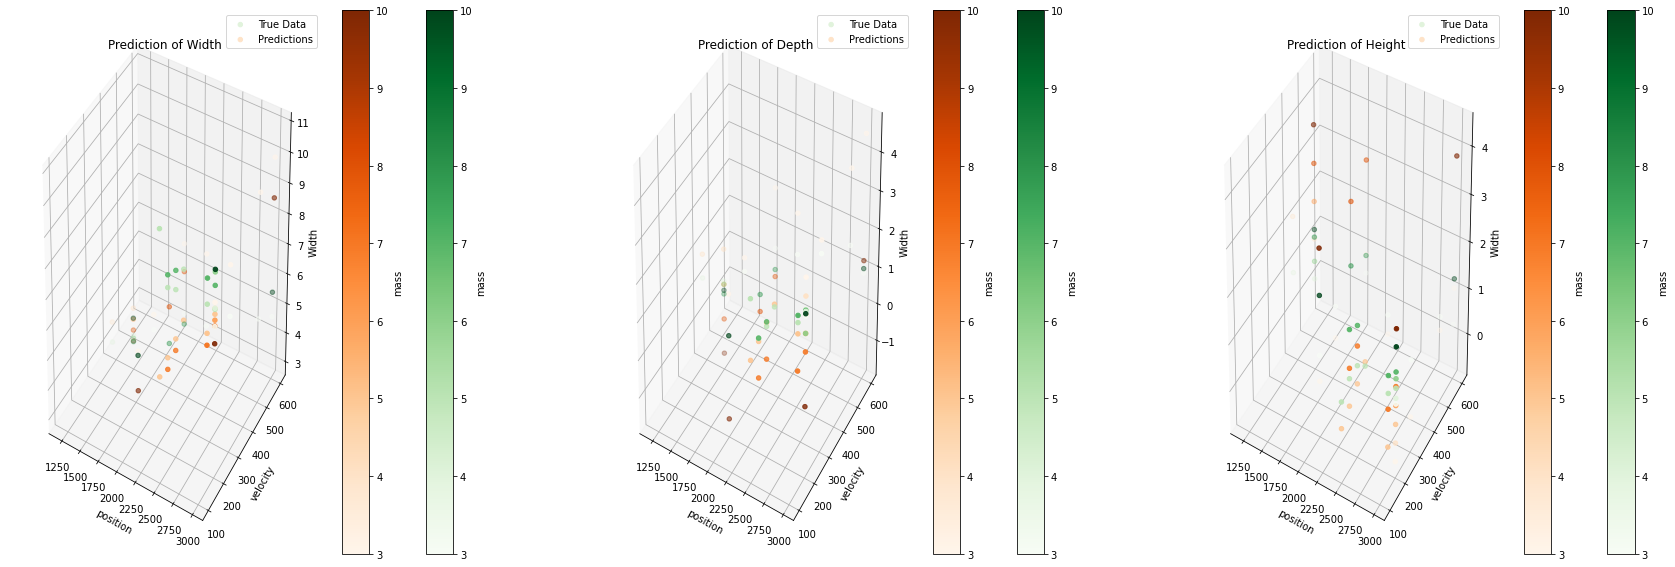

In [414]:
import matplotlib.pyplot as plt

# Clear figure
plt.clf()

# Get predictions
predicted = model(torch.from_numpy(x_train).requires_grad_()).data.numpy()

fig = plt.figure(figsize=(30, 10))

ax = fig.add_subplot(1,3,1,projection='3d')
img_mass_1 = ax.scatter3D(x_train[:,0],x_train[:,1],y_train[:,0],c=x_train[:,2],cmap='Greens',label='True Data')
img_mass_2 = ax.scatter3D(x_train[:,0],x_train[:,1],predicted[:,0],c=x_train[:,2],cmap='Oranges',label='Predictions')
fig.colorbar(img_mass_1,label='mass')
fig.colorbar(img_mass_2,label='mass')

ax.set_xlabel('position')
ax.set_ylabel('velocity')
ax.set_zlabel('Width')
ax.set_title('Prediction of Width')
ax.legend(loc='best')

ax = fig.add_subplot(1,3,2,projection='3d')
img_mass_1 = ax.scatter3D(x_train[:,0],x_train[:,1],y_train[:,1],c=x_train[:,2],cmap='Greens',label='True Data')
img_mass_2 = ax.scatter3D(x_train[:,0],x_train[:,1],predicted[:,1],c=x_train[:,2],cmap='Oranges',label='Predictions')
fig.colorbar(img_mass_1,label='mass')
fig.colorbar(img_mass_2,label='mass')

ax.set_xlabel('position')
ax.set_ylabel('velocity')
ax.set_zlabel('Width')
ax.set_title('Prediction of Depth')
ax.legend(loc='best')

ax = fig.add_subplot(1,3,3,projection='3d')
img_mass_1 = ax.scatter3D(x_train[:,0],x_train[:,1],y_train[:,2],c=x_train[:,2],cmap='Greens',label='True Data')
img_mass_2 = ax.scatter3D(x_train[:,0],x_train[:,1],predicted[:,2],c=x_train[:,2],cmap='Oranges',label='Predictions')
fig.colorbar(img_mass_1,label='mass')
fig.colorbar(img_mass_2,label='mass')

ax.set_xlabel('position')
ax.set_ylabel('velocity')
ax.set_zlabel('Width')
ax.set_title('Prediction of Height')
ax.legend(loc='best')

plt.show()